#### Questions
> Which region generates the highest sales?

> Which product category is the most profitable?

> Which products generate the highest revenue?

> Which customer segment contributes the most profit?

> What is the monthly sales trend?

#### `Step 0 :- Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Step 1 :- Load Dataset`

In [2]:
data_frame = pd.read_excel('Project_1_Retail_Sales_&_Profit_Analysis.xlsx')

# Quick look at data
print(f'Shape: {data_frame.shape}')

print(f'Total Columns:\n{data_frame.columns}')

data_frame.head()

Shape: (8399, 21)
Total Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin',
       'Ship Date'],
      dtype='str')


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,2012-01-10 00:00:00,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-02-10 00:00:00
2,50,293,2012-01-10 00:00:00,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-03-10 00:00:00
3,80,483,2011-10-07 00:00:00,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-12-07 00:00:00
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


#### `Step 2 :- Data Cleaning`

In [26]:
# Remove duplicate records (if any)
print(f"Before removing duplicates: {data_frame.shape}")

data_frame = data_frame.drop_duplicates()

print(f"After removing duplicates: {data_frame.shape}")

# Verify duplicate count
duplicate_count = data_frame.duplicated().sum()

print(f"Remaining duplicate rows: {duplicate_count}")

Before removing duplicates: (8399, 22)
After removing duplicates: (8399, 22)
Remaining duplicate rows: 0


In [4]:
# Check Missing Values
print(f'Missing values before handling:\n{data_frame.isnull().sum()}')

# List of Numeric Columns
numeric_columns = ['Order Quantity','Sales','Discount','Profit','Unit Price','Shipping Cost','Product Base Margin']

# Convert Numeric Columns
for column in numeric_columns:
    data_frame[column] = pd.to_numeric(data_frame[column], errors = 'coerce')

# Fill Missing Values for General Numeric Columns
other_numeric_columns = [column for column in numeric_columns if column != 'Product Base Margin']

data_frame[other_numeric_columns] = (data_frame[other_numeric_columns].fillna(0))

# Fill Missing Product Base Margin with Median
data_frame['Product Base Margin'] = (data_frame['Product Base Margin'].fillna(data_frame['Product Base Margin'].median()))

# List of Categorical Columns
categorical_columns = ['Region','Province','Customer Segment','Product Category','Product Sub-Category','Ship Mode']

# Fill Missing Categorical Values
for column in categorical_columns:
    data_frame[column] = data_frame[column].fillna('Unknown')

# Verify Missing Values
print(f'\nMissing values after handling:\n{data_frame.isnull().sum()}')

Missing values before handling:
Row ID                   0
Order ID                 0
Order Date               0
Order Priority           0
Order Quantity           0
Sales                    0
Discount                 0
Ship Mode                0
Profit                   0
Unit Price               0
Shipping Cost            0
Customer Name            0
Province                 0
Region                   0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Name             0
Product Container        0
Product Base Margin     63
Ship Date                0
dtype: int64

Missing values after handling:
Row ID                  0
Order ID                0
Order Date              0
Order Priority          0
Order Quantity          0
Sales                   0
Discount                0
Ship Mode               0
Profit                  0
Unit Price              0
Shipping Cost           0
Customer Name           0
Province                0
Region            

In [5]:
# Format Order Date and Ship Date properly
data_frame['Order Date'] = pd.to_datetime(data_frame['Order Date'], errors = 'coerce')

data_frame['Ship Date'] = pd.to_datetime(data_frame['Ship Date'], errors = 'coerce')

print(f'Order Date dtype: {data_frame['Order Date'].dtype}')

print(f'Ship Date dtype: {data_frame['Ship Date'].dtype}')

Order Date dtype: datetime64[us]
Ship Date dtype: datetime64[us]


In [6]:
# Standardize column names
data_frame.columns = data_frame.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')

print(f'Standardized Columns: {data_frame.columns.tolist()}')

Standardized Columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Order_Priority', 'Order_Quantity', 'Sales', 'Discount', 'Ship_Mode', 'Profit', 'Unit_Price', 'Shipping_Cost', 'Customer_Name', 'Province', 'Region', 'Customer_Segment', 'Product_Category', 'Product_Sub_Category', 'Product_Name', 'Product_Container', 'Product_Base_Margin', 'Ship_Date']


#### `Step 3 :- Data Analysis`

In [7]:
# Total Sales
total_sales = data_frame['Sales'].sum()

print(f'Total Sales: {total_sales:,.2f}')

Total Sales: 14,915,600.82


In [8]:
# Total Profit
total_profit = data_frame['Profit'].sum()

print(f'Total Profit: {total_profit:,.2f}')

Total Profit: 1,521,767.98


In [9]:
# Total Orders (unique Order IDs)
total_orders = data_frame['Order_ID'].nunique()

print(f'Total Order: {total_orders}')

Total Order: 5496


In [10]:
# Average Discount
average_discount = data_frame['Discount'].mean()

print(f'Average Discount: {average_discount:.2%}')

Average Discount: 4.97%


In [11]:
# Total Shipping Cost
total_shipping_cost = data_frame['Shipping_Cost'].sum()

print(f'Total Shipping Cost: {total_shipping_cost:,.2f}')

Total Shipping Cost: 107,831.04


#### `Step 4 :- Business Analysis`

In [12]:
# Sales by Region
sales_region = data_frame.groupby('Region')['Sales'].sum().sort_values(ascending = False)

sales_region.reset_index().style.format({'Sales': '{:,.2f}'})

,Region,Sales
0,West,"3,597,549.28"
1,Ontario,"3,063,212.48"
2,Prarie,"2,837,304.60"
3,Atlantic,"2,014,248.20"
4,Quebec,"1,510,195.08"
5,Yukon,"975,867.37"
6,Northwest Territories,"800,847.33"
7,Nunavut,"116,376.48"


In [13]:
# Sales by Product Category
sales_category = data_frame.groupby('Product_Category')['Sales'].sum().sort_values(ascending = False)

sales_category.reset_index().style.format({'Sales': '{:,.2f}'})

,Product_Category,Sales
0,Technology,"5,984,248.18"
1,Furniture,"5,178,590.54"
2,Office Supplies,"3,752,762.10"


In [14]:
# Top 10 Products by Sales
top_selling_products = data_frame.groupby('Product_Name')['Sales'].sum().sort_values(ascending = False).head(10)

top_selling_products.reset_index().style.format({'Sales': '{:,.2f}'})

,Product_Name,Sales
0,Global Troyª Executive Leather Low-Back Tilter,"275,941.52"
1,Polycom ViewStationª ISDN Videoconferencing Unit,"255,303.97"
2,Canon PC940 Copier,"210,910.68"
3,"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish","206,494.13"
4,Hewlett Packard LaserJet 3310 Copier,"194,880.35"
5,Bretford CR8500 Series Meeting Room Furniture,"147,412.21"
6,Sharp AL-1530CS Digital Copier,"130,046.81"
7,"Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers","128,100.43"
8,GBC DocuBind 200 Manual Binding Machine,"120,342.74"
9,Canon imageCLASS 2200 Advanced Copier,"114,173.41"


In [15]:
# Profit by Customer Segment
profit_segment = data_frame.groupby('Customer_Segment')['Profit'].sum().sort_values(ascending = False)

profit_segment.reset_index().style.format({'Profit': '{:,.2f}'})

,Customer_Segment,Profit
0,Corporate,"599,746.00"
1,Home Office,"318,354.03"
2,Small Business,"315,708.01"
3,Consumer,"287,959.94"


In [16]:
# Sales by Order Priority
sales_priority = data_frame.groupby('Order_Priority')['Sales'].sum().sort_values(ascending = False)

sales_priority.reset_index().style.format({'Sales': '{:,.2f}'})

,Order_Priority,Sales
0,Low,"3,282,630.38"
1,High,"3,267,356.36"
2,Medium,"2,862,452.12"
3,Not Specified,"2,778,363.30"
4,Critical,"2,724,798.67"


In [17]:
# Monthly Sales Trend (Using Order Date)

# Create year-month feature
data_frame['Year_Month'] = (data_frame['Order_Date'].dt.to_period('M'))

# Calculate monthly sales
monthly_sales = (data_frame.groupby('Year_Month', as_index = False)['Sales'].sum())

# Convert year-month to string for plotting
monthly_sales['Year_Month'] = (monthly_sales['Year_Month'].astype(str))

monthly_sales.reset_index().style.format({'Sales': '{:,.2f}'})

,index,Year_Month,Sales
0,0,2009-01,"379,695.02"
1,1,2009-02,"336,525.21"
2,2,2009-03,"411,076.41"
3,3,2009-04,"439,218.84"
4,4,2009-05,"382,541.09"
5,5,2009-06,"286,397.25"
6,6,2009-07,"339,817.04"
7,7,2009-08,"301,470.83"
8,8,2009-09,"307,395.89"
9,9,2009-10,"346,021.89"


In [18]:
# Profit by Product Category
profit_category = (data_frame.groupby('Product_Category')['Profit'].sum().sort_values(ascending = False))

print(f'Profit by Product Category:\n{profit_category}')

Profit by Product Category:
Product_Category
Technology         886313.52
Office Supplies    518021.43
Furniture          117433.03
Name: Profit, dtype: float64


#### `Step 5 :- Dashboard Creation`
> Create visualizations to summarize the business analysis and key performance indicators.

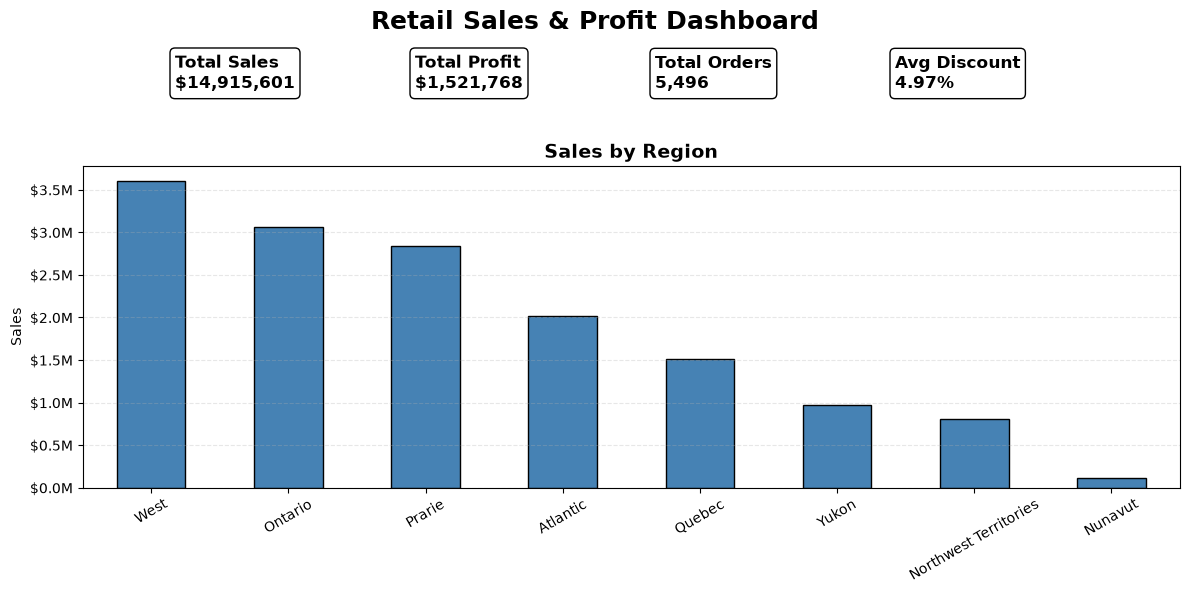

In [19]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(figsize=(12, 6))

# Dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis in millions
millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

# KPI Cards
dashboard_figure.text(
    0.15, 0.85,
    f'Total Sales\n${total_sales:,.0f}',
    fontsize = 12, fontweight = 'bold',
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black'))

dashboard_figure.text(
    0.35, 0.85,
    f'Total Profit\n${total_profit:,.0f}',
    fontsize = 12,
    fontweight = 'bold',
    bbox=dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black'))

dashboard_figure.text(
    0.55, 0.85,
    f'Total Orders\n{total_orders:,}',
    fontsize = 12,
    fontweight = 'bold',
    bbox=dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black'))

dashboard_figure.text(
    0.75, 0.85,
    f'Avg Discount\n{average_discount:.2%}',
    fontsize = 12,
    fontweight = 'bold',
    bbox=dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black'))

# Sales by Region Chart
sales_region.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'steelblue',
    edgecolor = 'black')

dashboard_axes.set_title(
    'Sales by Region',
    fontsize = 14,
    fontweight = 'bold')

dashboard_axes.set_xlabel('')

dashboard_axes.set_ylabel('Sales')

dashboard_axes.tick_params(axis = 'x', rotation = 30)

dashboard_axes.grid(axis = 'y', linestyle = '--', alpha = 0.3)

dashboard_axes.yaxis.set_major_formatter(millions_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_1_Chart.png',
    dpi = 300,
    bbox_inches = 'tight')

# Show dashboard
plt.show()

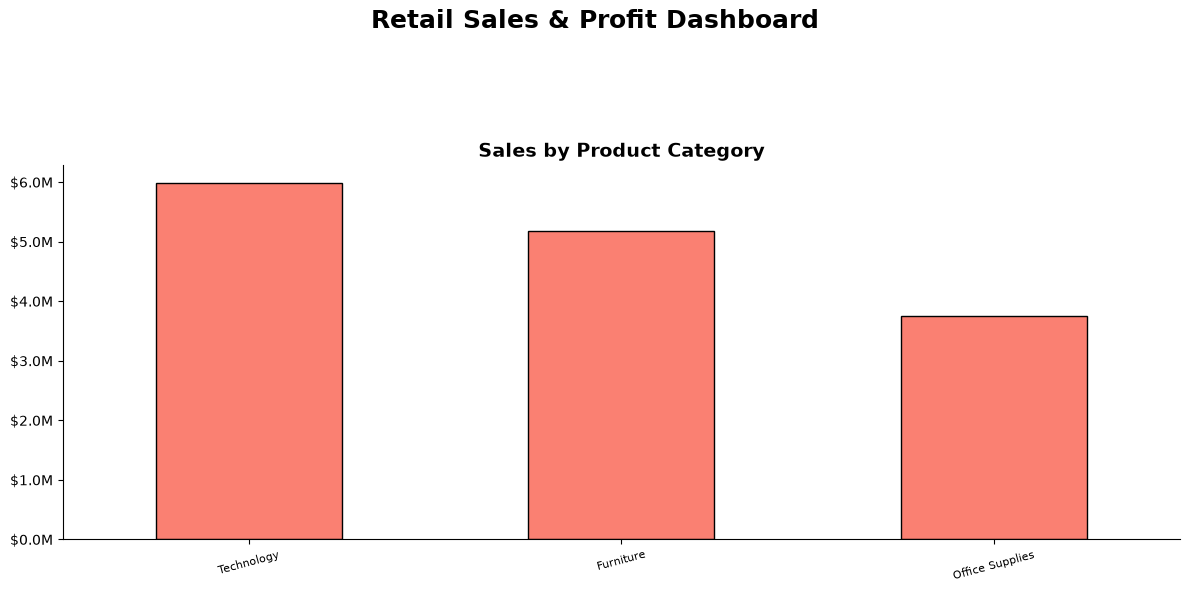

In [20]:
# Create dashboard layout
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

# Set dashboard background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis values in millions
millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

# Create Sales by Product Category chart
sales_category.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'salmon',
    edgecolor = 'black')

# Add chart title
dashboard_axes.set_title(
    'Sales by Product Category',
    fontsize = 14,
    fontweight = 'bold')

# Remove X-axis label
dashboard_axes.set_xlabel('')

# Rotate X-axis labels
dashboard_axes.tick_params(
    axis = 'x',
    rotation = 15,
    labelsize = 8)

# Remove top and right borders
dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

# Format Y-axis
dashboard_axes.yaxis.set_major_formatter(millions_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_2_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display chart
plt.show()

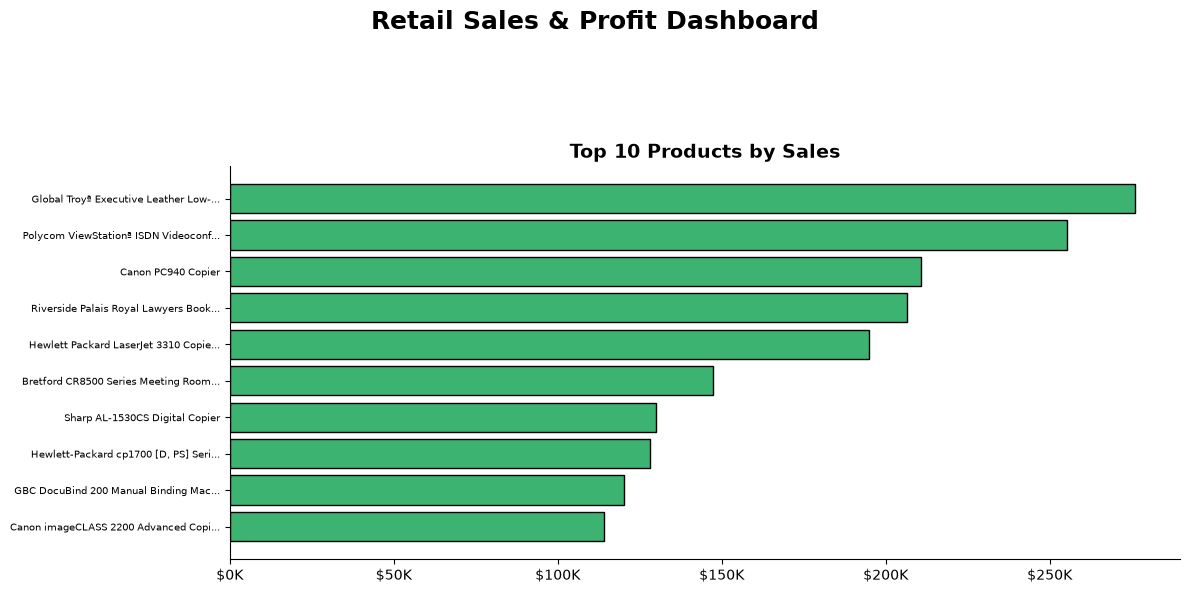

In [21]:
# Create dashboard layout
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

# Set dashboard background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format X-axis values in thousands
thousands_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K')

# Shorten long product names
short_product_names = [
    product_name[:35] + '...'
    if len(product_name) > 35
    else product_name
    for product_name in top_selling_products.index]

# Create Top 10 Products chart
dashboard_axes.barh(
    range(len(top_selling_products)),
    top_selling_products.values[::-1],
    color = 'mediumseagreen',
    edgecolor = 'black')

# Add product names
dashboard_axes.set_yticks(range(len(top_selling_products)))
dashboard_axes.set_yticklabels(
    short_product_names[::-1],
    fontsize = 7.5)

# Add chart title
dashboard_axes.set_title(
    'Top 10 Products by Sales',
    fontsize = 14,
    fontweight = 'bold')

# Remove top and right borders
dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

# Format X-axis
dashboard_axes.xaxis.set_major_formatter(thousands_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_3_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display chart
plt.show()

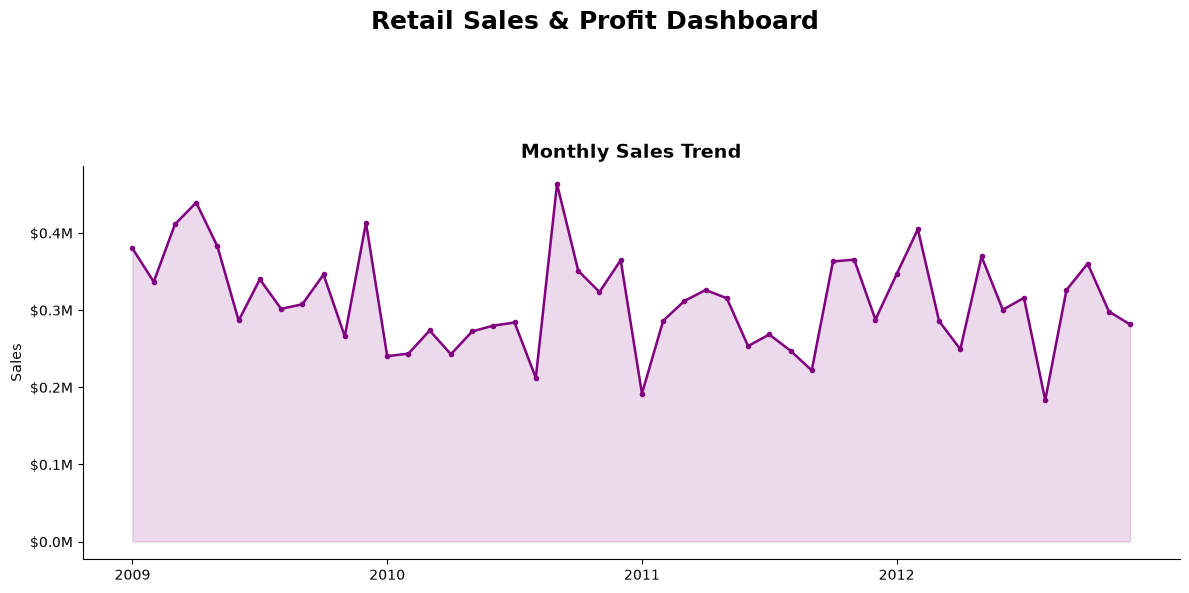

In [22]:
# Create dashboard layout
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

# Set dashboard background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis values in millions
millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

# Create X-axis positions
month_positions = range(len(monthly_sales))

# Create area chart
dashboard_axes.fill_between(
    month_positions,
    monthly_sales['Sales'],
    alpha = 0.15,
    color = 'purple')

# Create line chart
dashboard_axes.plot(
    month_positions,
    monthly_sales['Sales'],
    color = 'purple',
    linewidth = 1.8,
    marker = 'o',
    markersize = 3)

# Show year on X-axis
year_tick_positions = [
    index
    for index, year_month in enumerate(monthly_sales['Year_Month'])
    if year_month.endswith('-01')]

year_tick_labels = [
    monthly_sales['Year_Month'].iloc[index][:4]
    for index in year_tick_positions]

dashboard_axes.set_xticks(year_tick_positions)
dashboard_axes.set_xticklabels(year_tick_labels, fontsize = 10)

# Format X-axis
dashboard_axes.tick_params(axis = 'x', rotation = 0)

# Add chart title
dashboard_axes.set_title(
    'Monthly Sales Trend',
    fontsize = 14,
    fontweight = 'bold')

# Add Y-axis label
dashboard_axes.set_ylabel('Sales')

# Remove top and right borders
dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

# Format Y-axis
dashboard_axes.yaxis.set_major_formatter(millions_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_4_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display chart
plt.show()

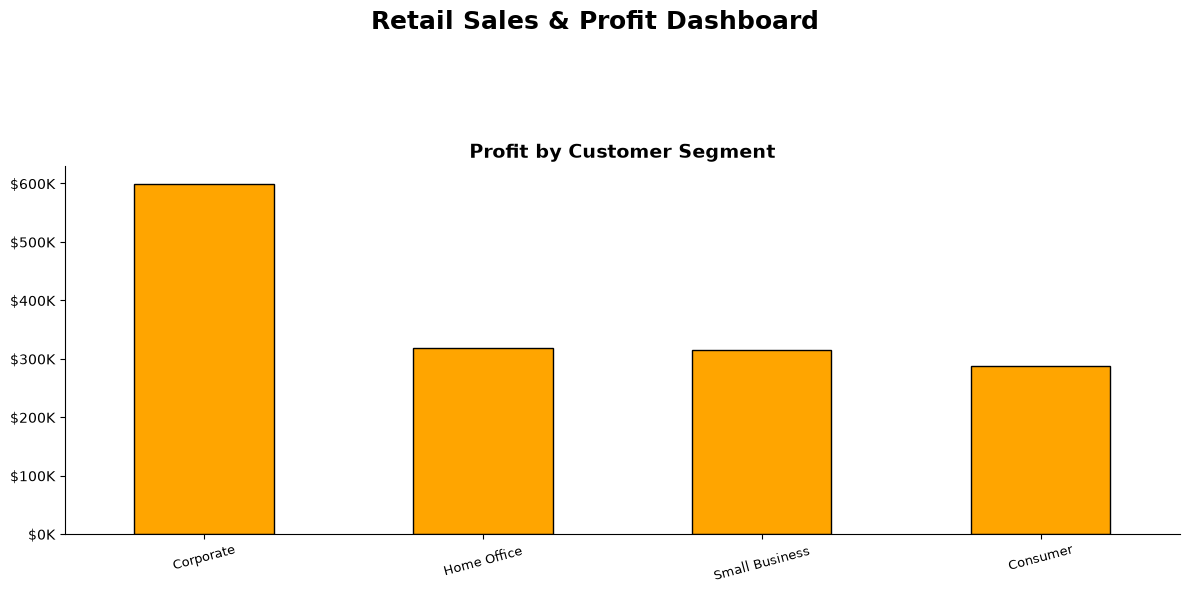

In [23]:
# Create dashboard layout
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

# Set dashboard background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis values in thousands
thousands_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K')

# Create Profit by Customer Segment chart
profit_segment.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'orange',
    edgecolor = 'black')

# Add chart title
dashboard_axes.set_title(
    'Profit by Customer Segment',
    fontsize = 14,
    fontweight = 'bold')

# Remove X-axis label
dashboard_axes.set_xlabel('')

# Rotate X-axis labels
dashboard_axes.tick_params(
    axis = 'x',
    rotation = 15,
    labelsize = 9)

# Remove top and right borders
dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

# Format Y-axis
dashboard_axes.yaxis.set_major_formatter(thousands_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_5_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display chart
plt.show()

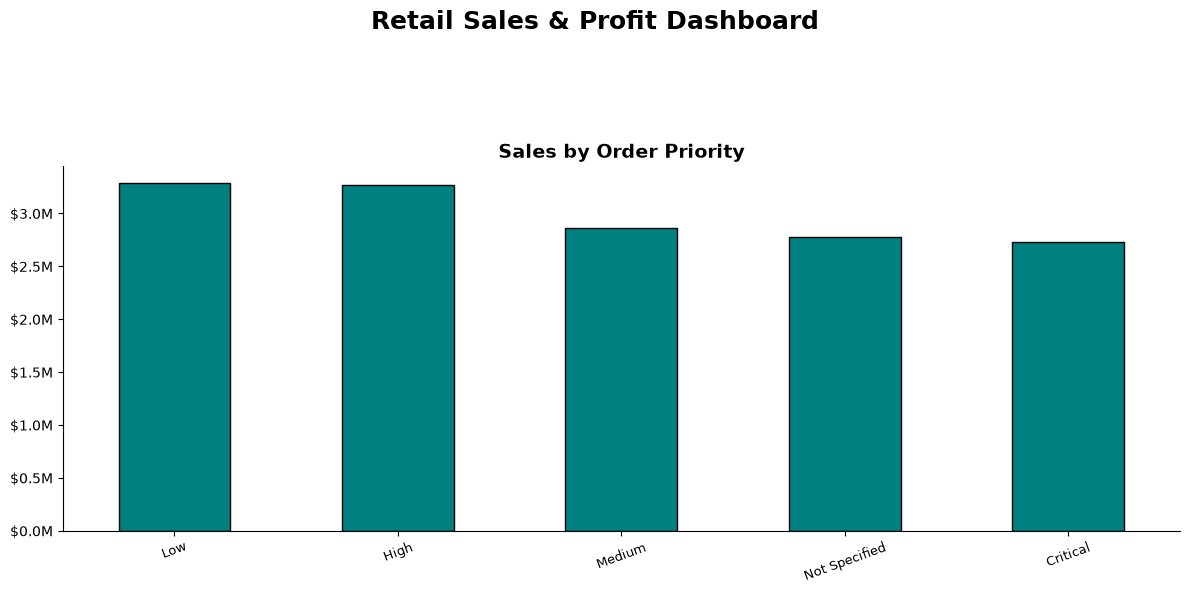

In [24]:
# Create dashboard layout
dashboard_figure, dashboard_axes = plt.subplots(figsize = (12, 6))

# Set dashboard background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 18,
    fontweight = 'bold')

# Format Y-axis values in millions
millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M')

# Create Sales by Order Priority chart
sales_priority.plot(
    kind = 'bar',
    ax = dashboard_axes,
    color = 'teal',
    edgecolor = 'black')

# Add chart title
dashboard_axes.set_title(
    'Sales by Order Priority',
    fontsize = 14,
    fontweight = 'bold')

# Remove X-axis label
dashboard_axes.set_xlabel('')

# Rotate X-axis labels
dashboard_axes.tick_params(
    axis = 'x',
    rotation = 20,
    labelsize = 9)

# Remove top and right borders
dashboard_axes.spines['top'].set_visible(False)
dashboard_axes.spines['right'].set_visible(False)

# Format Y-axis
dashboard_axes.yaxis.set_major_formatter(millions_formatter)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.85])

# Save chart
plt.savefig(
    '1_Project_6_Chart.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display chart
plt.show()

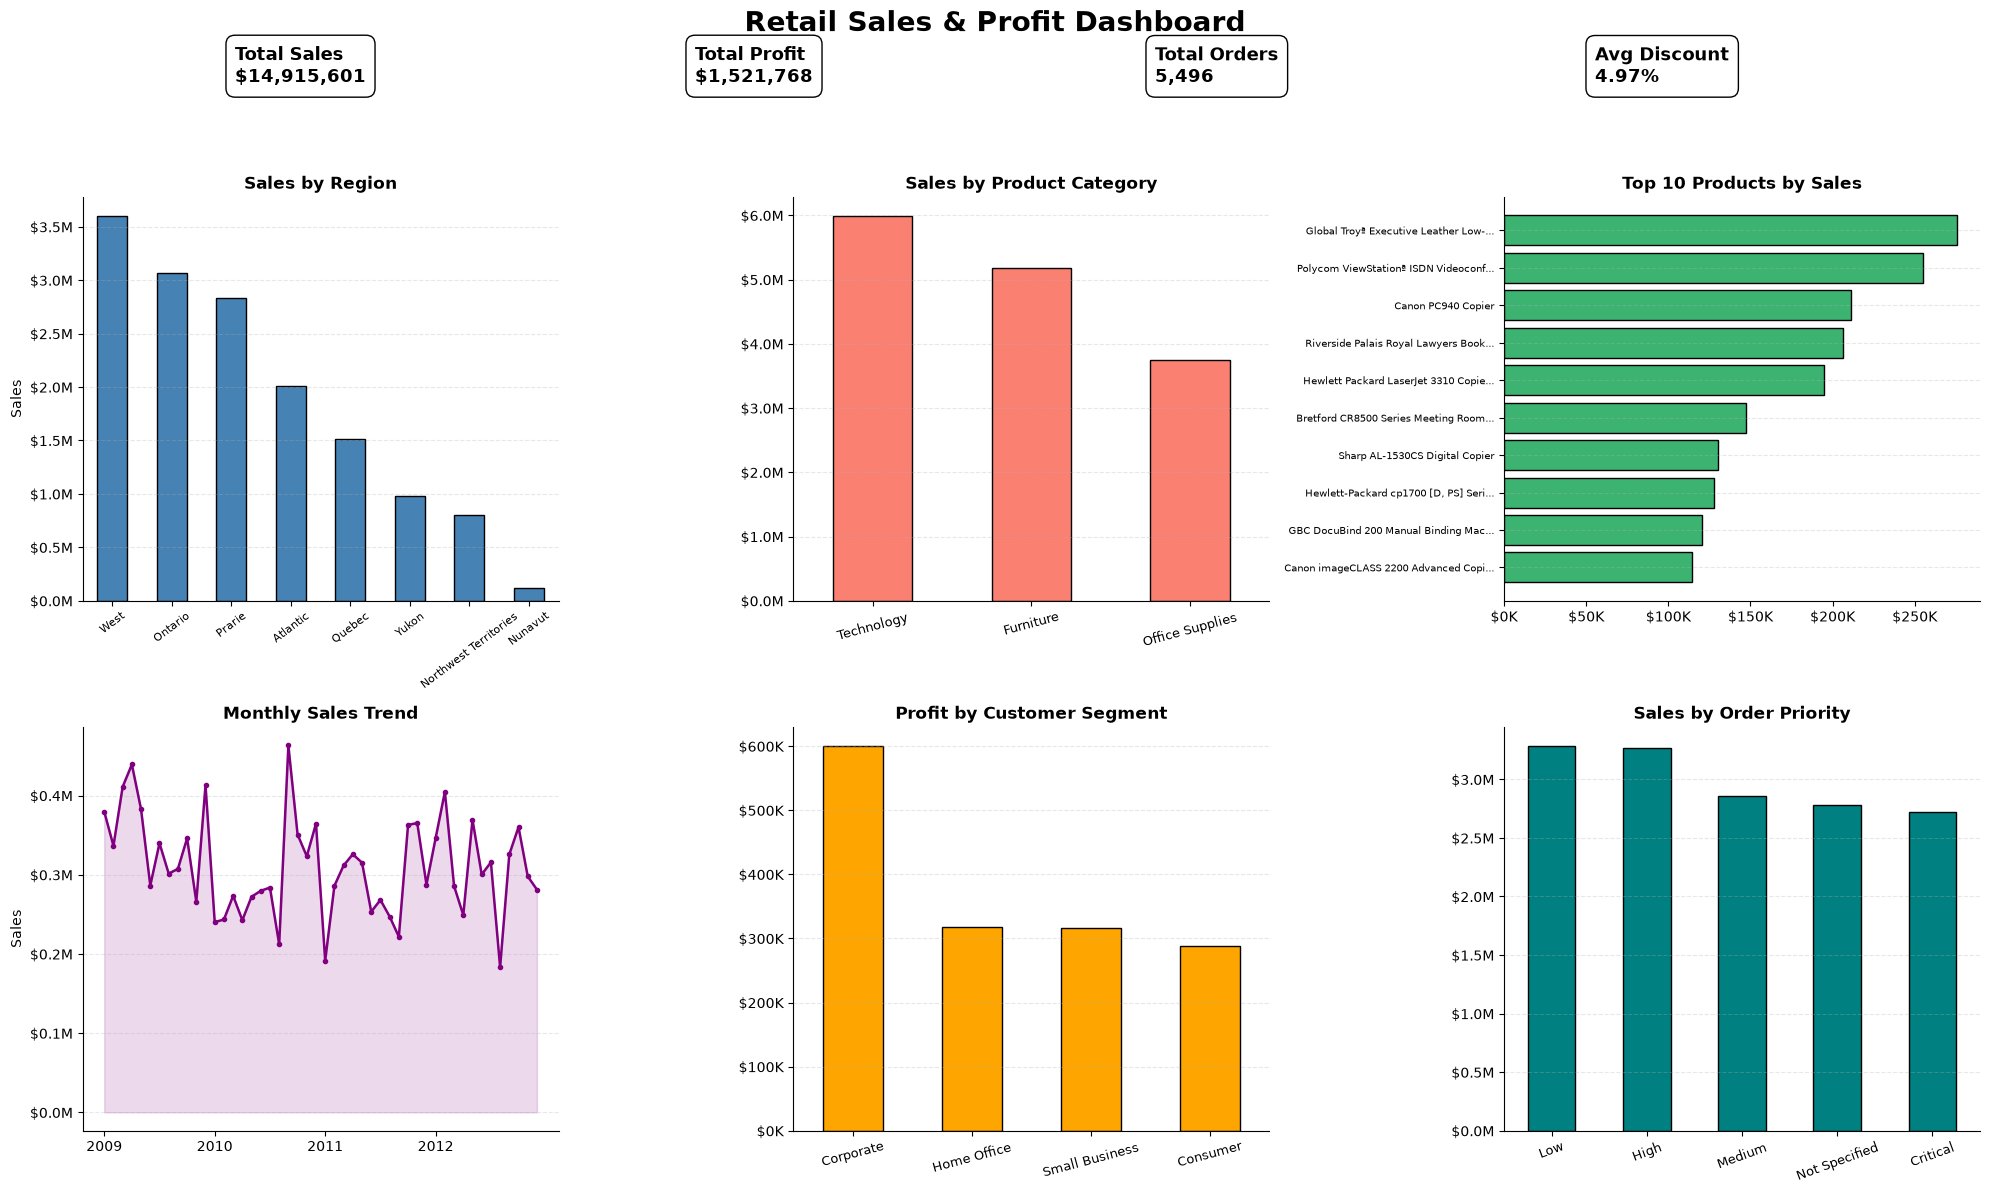

In [25]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(2, 3, figsize = (20, 12))

# Set background color
dashboard_figure.patch.set_facecolor('white')

# Add dashboard title
dashboard_figure.suptitle(
    'Retail Sales & Profit Dashboard',
    fontsize = 20,
    fontweight = 'bold',
    y = 0.99)

# Show KPI cards
dashboard_figure.text(
    0.12, 0.93,
    f'Total Sales\n${total_sales:,.0f}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.35, 0.93,
    f'Total Profit\n${total_profit:,.0f}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.58, 0.93,
    f'Total Orders\n{total_orders:,}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

dashboard_figure.text(
    0.80, 0.93,
    f'Avg Discount\n{average_discount:.2%}',
    fontsize = 13,
    fontweight = 'bold',
    bbox = dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round, pad = 0.5'))

# Format chart values
millions_formatter = plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
thousands_formatter = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')

# Chart 1: Sales by Region
sales_region.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 0],
    color = 'steelblue',
    edgecolor = 'black')

dashboard_axes[0, 0].set_title('Sales by Region', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 0].set_xlabel('')
dashboard_axes[0, 0].set_ylabel('Sales')
dashboard_axes[0, 0].tick_params(axis = 'x', rotation = 37, labelsize = 8)
dashboard_axes[0, 0].yaxis.set_major_formatter(millions_formatter)

# Chart 2: Sales by Product Category
sales_category.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 1],
    color = 'salmon',
    edgecolor = 'black')

dashboard_axes[0, 1].set_title('Sales by Product Category', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 1].set_xlabel('')
dashboard_axes[0, 1].tick_params(axis = 'x', rotation = 15, labelsize = 9)
dashboard_axes[0, 1].yaxis.set_major_formatter(millions_formatter)

# Chart 3: Top 10 Products by Sales
short_product_names = [
    product_name[:35] + '...'
    if len(product_name) > 35
    else product_name
    for product_name in top_selling_products.index]

dashboard_axes[0, 2].barh(
    range(len(top_selling_products)),
    top_selling_products.values[::-1],
    color = 'mediumseagreen',
    edgecolor = 'black')

dashboard_axes[0, 2].set_yticks(range(len(top_selling_products)))
dashboard_axes[0, 2].set_yticklabels(short_product_names[::-1], fontsize = 7.5)
dashboard_axes[0, 2].set_title('Top 10 Products by Sales', fontsize = 12, fontweight = 'bold')
dashboard_axes[0, 2].xaxis.set_major_formatter(thousands_formatter)

# Chart 4: Monthly Sales Trend
month_positions = range(len(monthly_sales))

dashboard_axes[1, 0].fill_between(
    month_positions,
    monthly_sales['Sales'],
    alpha = 0.15,
    color = 'purple')

dashboard_axes[1, 0].plot(
    month_positions,
    monthly_sales['Sales'],
    color = 'purple',
    linewidth = 1.8,
    marker = 'o',
    markersize = 3)

year_tick_positions = [
    index
    for index, year_month in enumerate(monthly_sales['Year_Month'])
    if year_month.endswith('-01')]

year_tick_labels = [
    monthly_sales['Year_Month'].iloc[index][:4]
    for index in year_tick_positions]

dashboard_axes[1, 0].set_xticks(year_tick_positions)
dashboard_axes[1, 0].set_xticklabels(year_tick_labels, fontsize = 10)
dashboard_axes[1, 0].tick_params(axis = 'x', rotation = 0)
dashboard_axes[1, 0].set_title('Monthly Sales Trend', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 0].set_ylabel('Sales')
dashboard_axes[1, 0].yaxis.set_major_formatter(millions_formatter)

# Chart 5: Profit by Customer Segment
profit_segment.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 1],
    color = 'orange',
    edgecolor = 'black')

dashboard_axes[1, 1].set_title('Profit by Customer Segment', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 1].set_xlabel('')
dashboard_axes[1, 1].tick_params(axis = 'x', rotation = 15, labelsize = 9)
dashboard_axes[1, 1].yaxis.set_major_formatter(thousands_formatter)

# Chart 6: Sales by Order Priority
sales_priority.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 2],
    color = 'teal',
    edgecolor = 'black')

dashboard_axes[1, 2].set_title('Sales by Order Priority', fontsize = 12, fontweight = 'bold')
dashboard_axes[1, 2].set_xlabel('')
dashboard_axes[1, 2].tick_params(axis = 'x', rotation = 20, labelsize = 9)
dashboard_axes[1, 2].yaxis.set_major_formatter(millions_formatter)

# Format all charts
for row in dashboard_axes:
    for chart in row:
        chart.grid(axis = 'y', linestyle = '--', alpha = 0.3)
        chart.spines['top'].set_visible(False)
        chart.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.90])

# Save dashboard
plt.savefig(
    '1_Project.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = dashboard_figure.get_facecolor())

# Display dashboard
plt.show()

#### Information

> Dataset: Retail Sales (Orders, Customers, Products, Regions)

> Total Rows: 8,399

> Original Columns: 21

> Final Columns: 22

> Added Feature: Year_Month (from Order_Date)

> Missing values in Product Base Margin were filled using the median.

#### Data Insights
> Total Sales: $14.92M

> Total Profit: $1.52M

> Technology generated the highest sales.

> West region recorded the highest sales.

> Corporate customers generated the highest profit.

> Average Discount: 4.97%

> Furniture generated high sales but relatively low profit.

#### Business Insights

> Technology is the best-performing product category.

> Corporate is the most profitable customer segment.

> West is the highest sales region.

> Average discount is well controlled.

> Furniture sales are high, but profitability is comparatively low.

#### Risks

> High dependence on Technology category.

> Low sales in some regions.

> High discounts may reduce profit.

#### Opportunities

> Increase Technology product sales.

> Improve sales in low-performing regions.

> Focus more on profitable customer segments.

#### Recommendations

> Increase investment in the Technology category.

> Focus on Corporate customers.

> Maintain a controlled discount strategy.

> Improve sales performance in low-performing regions.

> Review pricing and costs for Furniture products.

#### Expected Business Impact

> Increase sales.

> Improve profitability.

> Better regional performance.

> Better customer focus.

#### Future Prediction

> Technology products and Corporate customers are expected to remain strong contributors if current trends continue.